# NHS A&E Performance Analysis
**Author:** Husnain Zahoor  
**Date:** Aug 05, 2026   
**Dataset:** NHS A&E Quality Indicators (Provisional, December 2023 – December 2025)  
**Source URL:** https://tinyurl.com/NHS-Source-Data

---

### Context & Pipeline Position
This notebook (3 of 4) imports `df_analysis.pkl` to generate four publication-grade Matplotlib/Seaborn figures illustrating wait time trends, organizational distributions, and reattendance patterns. All charts are exported as high-resolution PNGs to the `output/` directory for inclusion in the stakeholder deck and final report.

## Environment Setup
Mount Google Drive and define standard file paths. Run these three cells at the start of every session.

In [ ]:
# Mount Google Drive — run this first in every session
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define standard paths — reference these throughout the module
DATA_PATH   = '/content/drive/My Drive/Lumen/python-data-analytics/Data/'
OUTPUT_PATH = '/content/drive/My Drive/Lumen/python-data-analytics/Output/'

In [ ]:
# Verify setup — confirm all three CSV files are accessible
import os
print(os.listdir(DATA_PATH))

['aeqi_metadata.csv', 'aeqi_open_data_2025_12.csv', 'nhs_trust_reference.csv']


## Library Imports

In [ ]:
# Setup and Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl
import os

# FORCE PANDAS TO SHOW ALL COLUMNS HORIZONTALLY (NO WRAPPING)
pd.set_option('display.max_columns', None)  # Show every column
pd.set_option('display.width', 1000)        # Give the text engine plenty of horizontal width

In [ ]:
df_analysis = pd.read_pickle(OUTPUT_PATH + 'df_analysis.pkl')
print(df_analysis.shape)

(78386, 22)


In [ ]:
# Apply a clean, professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Set default figure size (can be overridden per chart)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

##Bar Chart

Horizontal bar chart, the **worst** performers.

**Bussiness Questions:** Which top **10 NHS Trusts** have the longest mean A&E wait times across the full 25-month period?

In [ ]:
# Preparation of Data:
aeqi051 = df_analysis[df_analysis['MEASURE_ID'] == 'AEQI051'].copy()

top10 =(aeqi051.groupby(['ORG_CODE', 'ORG_NAME'])['MEASURE_VALUE'].mean().nlargest(10).reset_index())
top10.columns = ['ORG_CODE','ORG_NAME', 'mean_wait_time']

# Short the Name of Organizations:
top10['short_name'] = top10['ORG_NAME'].str.replace('NHS FOUNDATION TRUST', '', regex=False)
top10['short_name'] = top10['short_name'].str.replace('NHS TRUST', '', regex=False)
top10['short_name'] = top10['short_name'].str.title()

# Sort values:
top10 = top10.sort_values('mean_wait_time', ascending=True)


In [ ]:
# Confirming National Median:
df_raw = pd.read_csv(DATA_PATH + 'aeqi_open_data_2025_12.csv')
national_median = df_raw[(df_raw['ORG_CODE'] == 'ENG') &(df_raw['MEASURE_ID'] == 'AEQI051')]['MEASURE_VALUE'].median()
print(f"National Median: {national_median}")

National Median: 169.0


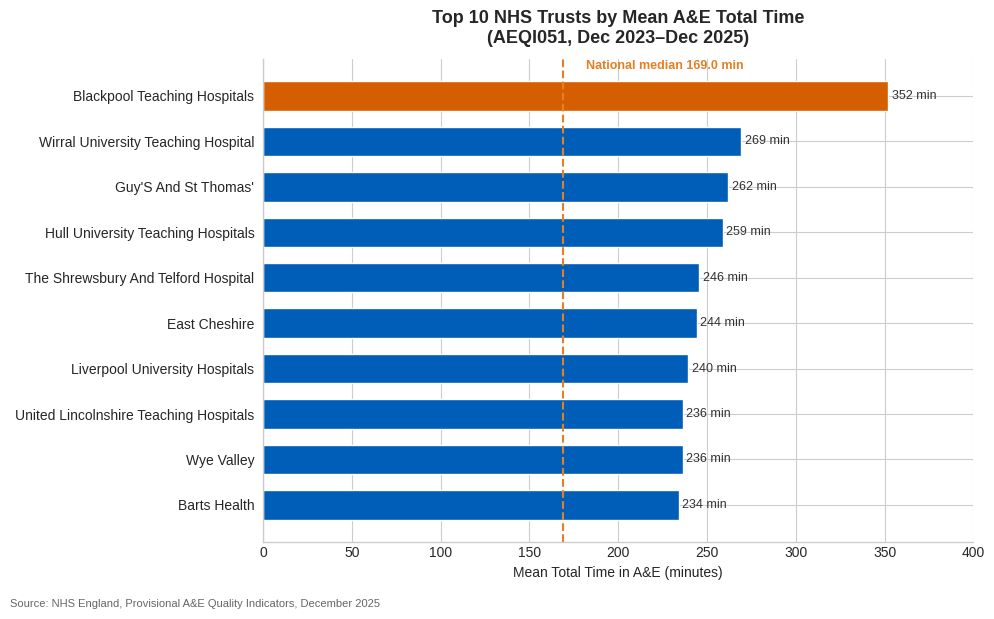

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create a list of 9 blue colors, and make the 10th (last) one red
bar_colors = ['#005EB8'] * 9 + ['#D55E00']  # NHS Blue for 9 bars, dark red for the last one

# Now pass that list into your chart code
bars = ax.barh(
    top10['short_name'],
    top10['mean_wait_time'],
    color=bar_colors,   # Use our dynamic color list here!
    edgecolor='white',
    height=0.65
)

# Add value labels on each bar
for bar in bars:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.0f} min',
        va='center', fontsize=9, color='#333'
    )
# Use actual calculated database median
ax.axvline(x=169, color='#E67E22', linestyle='--', linewidth=1.5)
ax.text(182, 9.6, 'National median 169.0 min', color='#E67E22', fontsize=9, fontweight='bold')


# Titles and labels
ax.set_title(
    'Top 10 NHS Trusts by Mean A&E Total Time\n(AEQI051, Dec 2023–Dec 2025)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Mean Total Time in A&E (minutes)', fontsize=10)
ax.set_ylabel('')
ax.set_xlim(0, 400)


# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data source annotation (NHS standard practice)
fig.text(
    0.01, -0.02,
    'Source: NHS England, Provisional A&E Quality Indicators, December 2025',
    fontsize=8, color='#666'
)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart_top10_wait_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Gemini** gave generic advice for a **7-category** comparison chart (e.g. bar chart of 7 NHS regions, each a distinct category). But Bar Chart is not like that. we have **10 bars** representing the same variable **(mean A&E wait time)** for 10 different Trusts, with one bar highlighted as an outlier (Blackpool). That's a fundamentally different chart type:

Applying 7 distinct colours (Okabe-Ito) across 10 bars would imply the Trusts belong to different categorical groups they don't. It would mislead a viewer into thinking there's a grouping variable (e.g. region) driving colour, when there isn't.
Actual need is: **9 bars in one neutral colour + 1 bar highlighted in a contrasting colour, which is exactly what you already built (blue vs red/orange).**

##Line Chart
Line chart national trend.

**Business question:** How has England’s national median A&E total time changed month by month from December 2023 to December 2025?

In [ ]:
# Load the original file to access the England aggregate
df_raw = pd.read_csv(DATA_PATH + 'aeqi_open_data_2025_12.csv')

# Filter to England aggregate, AEQI051
eng_trend = df_raw[(df_raw['ORG_CODE'] == 'ENG') &(df_raw['MEASURE_ID'] == 'AEQI051')].copy()

# ConvertING ATTENDANCE_MONTH to datetime
eng_trend['month_dt'] = pd.to_datetime(eng_trend['ATTENDANCE_MONTH'], format='%Y-%m')
eng_trend = eng_trend.sort_values('month_dt')

print(eng_trend[['ATTENDANCE_MONTH', 'MEASURE_VALUE']].to_string(index=False))

# Find peak and trough dynamically.
peak_row = eng_trend.loc[eng_trend['MEASURE_VALUE'].idxmax()]
trough_row = eng_trend.loc[eng_trend['MEASURE_VALUE'].idxmin()]

print(f"Peak: {peak_row['MEASURE_VALUE']} min ({peak_row['ATTENDANCE_MONTH']})")
print(f"Trough: {trough_row['MEASURE_VALUE']} min ({trough_row['ATTENDANCE_MONTH']})")

ATTENDANCE_MONTH  MEASURE_VALUE
         2023-12          186.0
         2024-01          183.0
         2024-02          182.0
         2024-03          175.0
         2024-04          168.0
         2024-05          172.0
         2024-06          169.0
         2024-07          166.0
         2024-08          157.0
         2024-09          169.0
         2024-10          172.0
         2024-11          179.0
         2024-12          180.0
         2025-01          169.0
         2025-02          171.0
         2025-03          170.0
         2025-04          166.0
         2025-05          164.0
         2025-06          164.0
         2025-07          160.0
         2025-08          159.0
         2025-09          164.0
         2025-10          166.0
         2025-11          167.0
         2025-12          165.0
Peak: 186.0 min (2023-12)
Trough: 157.0 min (2024-08)


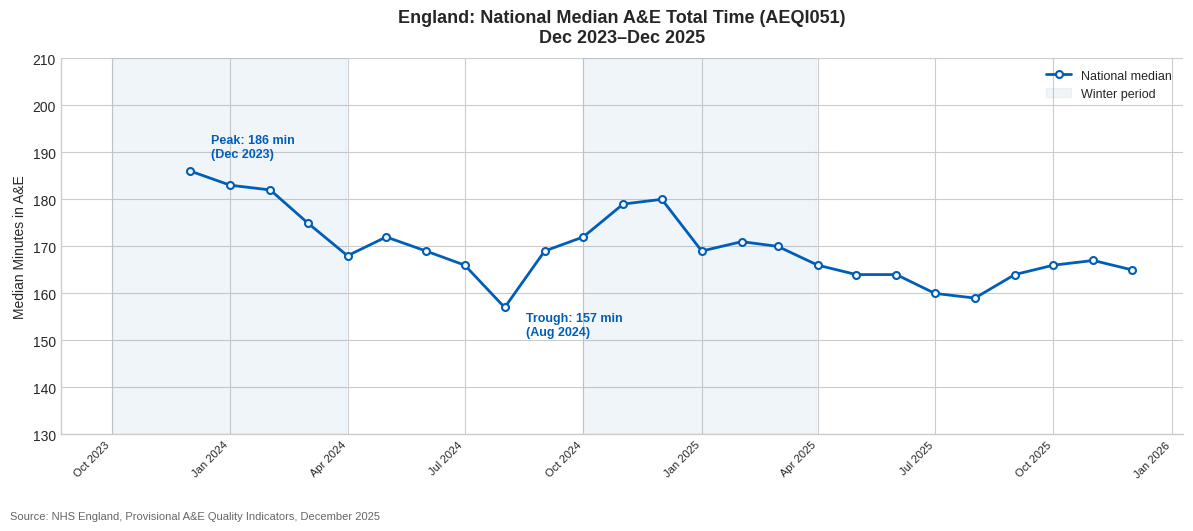

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    eng_trend['month_dt'],
    eng_trend['MEASURE_VALUE'],
    color='#005EB8',
    linewidth=2,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5
)

# Shade winter periods (Oct-Mar) to contextualise seasonal patterns
for yr in [2024, 2025]:
    ax.axvspan(
        pd.Timestamp(f'{yr-1}-10-01'),
        pd.Timestamp(f'{yr}-03-31'),
        alpha=0.08, color='steelblue', label='Winter' if yr == 2024 else ''
    )

# Peak and trough annotations dynamic values, orange colour
ax.annotate(
    f"Peak: {peak_row['MEASURE_VALUE']:.0f} min\n({peak_row['month_dt'].strftime('%b %Y')})",
    xy=(peak_row['month_dt'], peak_row['MEASURE_VALUE']),
    xytext=(15, 10), textcoords='offset points',
    fontsize=9, color='#005EB8', fontweight='bold'
)

ax.annotate(
    f"Trough: {trough_row['MEASURE_VALUE']:.0f} min\n({trough_row['month_dt'].strftime('%b %Y')})",
    xy=(trough_row['month_dt'], trough_row['MEASURE_VALUE']),
    xytext=(15, -20), textcoords='offset points',
    fontsize=9, color='#005EB8', fontweight='bold'
)

ax.set_title(
    'England: National Median A&E Total Time (AEQI051)\nDec 2023–Dec 2025',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_ylabel('Median Minutes in A&E', fontsize=10)
ax.set_xlabel('')
ax.set_ylim(130, 210)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(['National median', 'Winter period'], fontsize=9)

fig.text(
    0.01, -0.05,
    'Source: NHS England, Provisional A&E Quality Indicators, December 2025',
    fontsize=8, color='#666'
)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart_england_trend.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

This chart tracks England's national median A&E total time,
month by month, from December 2023 to December 2025 — two full
years of data.

The winter periods, shaded in blue, show a repeating pattern:
wait times climb each winter and fall back in warmer months.
The clearest peak is December 2024, at 180 minutes — almost
back to where the trend started a year earlier. This confirms
winter pressure is a recurring, predictable feature of the
system, not a one-off event.

##Histograms

Histogram reattendance distribution.

**Business question:** What is the distribution of reattendance rates across all NHS Trusts?

In [ ]:
aeqi062 = df_analysis[df_analysis['MEASURE_ID'] == 'AEQI062'].copy()

# One value per Trust: mean reattendance rate across all months
trust_reattend = aeqi062.groupby('ORG_CODE')['MEASURE_VALUE'].mean().reset_index()
trust_reattend.columns = ['ORG_CODE', 'mean_reattend']

In [ ]:
reattendance_mean = trust_reattend['mean_reattend'].mean()
print(f"reattendance_mean: {reattendance_mean}")

reattendance_median = trust_reattend['mean_reattend'].median()
print(f"reattendance_median: {reattendance_median}")

reattendance_mean: 8.706028710669006
reattendance_median: 8.83366691299488


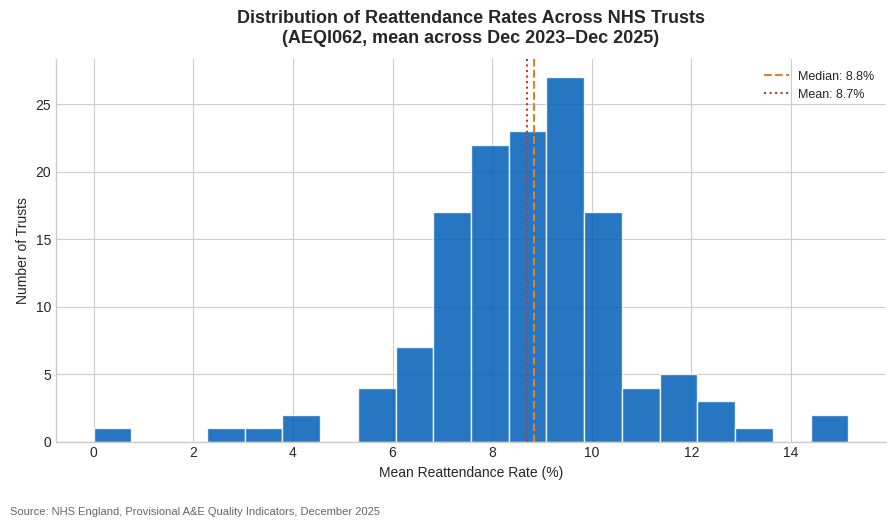

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    trust_reattend['mean_reattend'],
    bins=20,
    color='#005EB8',
    edgecolor='white',
    alpha=0.85
)

# Add median and mean lines
median_val = trust_reattend['mean_reattend'].median()
mean_val = trust_reattend['mean_reattend'].mean()

ax.axvline(median_val, color='#e67e22', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}%')
ax.axvline(mean_val, color='#c0392b', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.1f}%')

ax.set_title('Distribution of Reattendance Rates Across NHS Trusts\n(AEQI062, mean across Dec 2023–Dec 2025)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mean Reattendance Rate (%)', fontsize=10)
ax.set_ylabel('Number of Trusts', fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.01, -0.04, 'Source: NHS England, Provisional A&E Quality Indicators, December 2025', fontsize=8, color='#666')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart_reattendance_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

The distribution is approximately normal, with mean (8.7%) and median (8.8%)
nearly identical. However, 27 of 137 Trusts (~20%) sit above 10% reattendance —
a meaningful tail worth investigating rather than treating as noise.

In [ ]:
tail = trust_reattend[trust_reattend['mean_reattend'] > 10]
print(len(tail))
print(tail.sort_values('mean_reattend', ascending=True))

27
    ORG_CODE  mean_reattend
34       REM      10.023147
92       RTE      10.025093
5        R1H      10.107377
134      RYR      10.196617
112      RWG      10.289251
8        RA7      10.304613
9        RA9      10.329485
14       RAT      10.385825
6        R1K      10.438947
1        R0B      10.450682
90       RRV      10.470723
55       RJE      10.512575
22       RC9      10.685151
68       RM3      10.722731
59       RJZ      10.923135
85       RQX      11.173464
135      RYX      11.592109
50       RJ1      11.608713
15       RAX      11.790250
104      RVV      11.932818
127      RXR      11.986714
122      RXK      12.378081
35       REP      12.426457
107      RW4      12.577785
36       RF4      13.610032
111      RWF      14.674176
93       RTF      15.153425


##Scatter Plots

Scatter plot treatment time vs. reattendance.

**Business question:** Is there a relationship between time-to-treatment and reattendance rate? Do Trusts that keep patients waiting longer for treatment tend to see higher rates of patients returning within 7 days?

In [ ]:
# Build the scatter dataset: one row per Trust
aeqi041 = df_analysis[df_analysis['MEASURE_ID'] == 'AEQI041'].groupby('ORG_CODE')['MEASURE_VALUE'].mean().reset_index()
aeqi041.columns = ['ORG_CODE', 'mean_treat_time']

aeqi062 = df_analysis[df_analysis['MEASURE_ID'] == 'AEQI062'].groupby('ORG_CODE')['MEASURE_VALUE'].mean().reset_index()
aeqi062.columns = ['ORG_CODE', 'mean_reattend']

scatter_df = aeqi041.merge(aeqi062, on='ORG_CODE')
scatter_df = scatter_df[(scatter_df['mean_treat_time'] > 0) & (scatter_df['mean_reattend'] > 0)]
print(f'{len(scatter_df)} Trusts with both KPIs')

135 Trusts with both KPIs


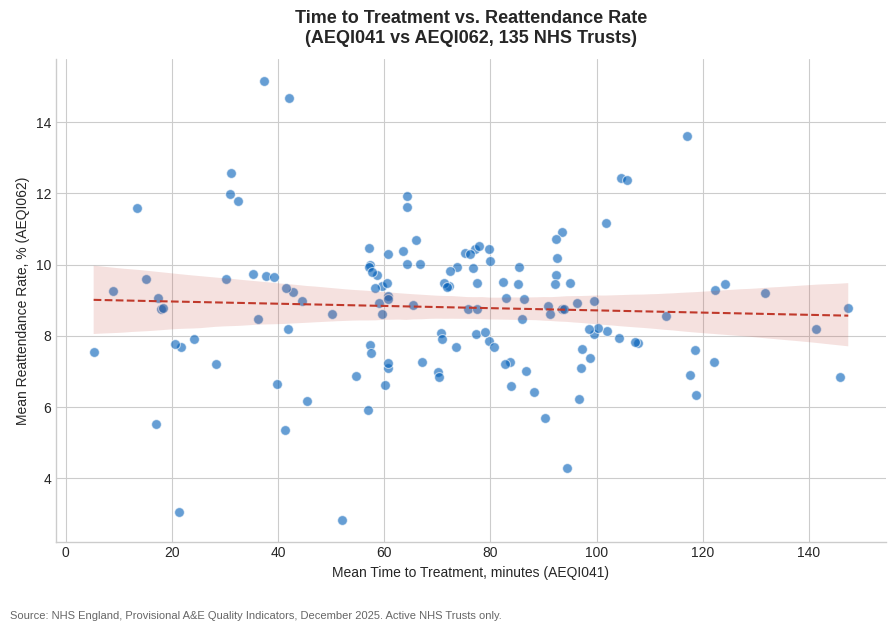

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    scatter_df['mean_treat_time'],
    scatter_df['mean_reattend'],
    color='#005EB8',
    alpha=0.6,
    s=50,
    edgecolors='white',
    linewidth=0.8
)

# Add a regression line (seaborn does this cleanly)
import seaborn as sns
sns.regplot(
    data=scatter_df,
    x='mean_treat_time', y='mean_reattend',
    scatter=False,
    color='#c0392b',
    line_kws={'linewidth': 1.5, 'linestyle': '--'},
    ci=95,
    ax=ax
)

ax.set_title('Time to Treatment vs. Reattendance Rate\n(AEQI041 vs AEQI062, 135 NHS Trusts)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mean Time to Treatment, minutes (AEQI041)', fontsize=10)
ax.set_ylabel('Mean Reattendance Rate, % (AEQI062)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.01, -0.04, 'Source: NHS England, Provisional A&E Quality Indicators, December 2025. Active NHS Trusts only.', fontsize=8, color='#666')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart_treatment_vs_reattendance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
top2_outlier = scatter_df.sort_values('mean_reattend', ascending=False).head(2)
print(top2_outlier)

    ORG_CODE  mean_treat_time  mean_reattend
93       RTF            37.32      15.153425
111      RWF            42.16      14.674176


In [ ]:
# Outlier Organizations Name:
top2_outlier = df_analysis[df_analysis['ORG_CODE'].isin(top2_outlier['ORG_CODE'])][['ORG_CODE','ORG_NAME']].drop_duplicates()
print(top2_outlier)

    ORG_CODE                                     ORG_NAME
626      RTF  NORTHUMBRIA HEALTHCARE NHS FOUNDATION TRUST
972      RWF      MAIDSTONE AND TUNBRIDGE WELLS NHS TRUST


The regression line shows a weak negative slope: as mean time-to-treatment
increases, reattendance rate decreases slightly. With 135 points scattered
this widely, the relationship is not meaningful.

This is counterintuitive — longer waits would normally suggest worse
outcomes. A likely explanation is clinical case-mix: Trusts treating
higher-acuity patients may take longer per case but still discharge
appropriately, breaking the expected pattern.

Northumbria Healthcare NHS Foundation Trust and Maidstone and Tunbridge
Wells NHS Trust stand out as outliers. Both have fast treatment times
(37.3 and 42.2 minutes) but the two highest reattendance rates in the
dataset (15.2% and 14.7%). This suggests treatment speed alone does not
explain return-visit risk for these two Trusts.

## Export & Verfiy Charts:

In [ ]:
import os;
print(os.listdir(OUTPUT_PATH))

['.ipynb_checkpoints', 'population_flow.csv', 'df_final_backup.csv', 'df_analysis.csv', 'aeqi_published.csv', 'aeqi_wrangled.csv', 'df_aeqi_clean.pkl', 'data_dictionary.csv', 'chart_top10_wait_time.png', 'chart_treatment_vs_reattendance.png', 'chart_reattendance_distribution.png', 'chart_england_trend.png', 'derivations_log.csv', 'consistency_checks.csv', 'NHS_A&E_Report.xlsx', 'df_final.pkl', 'pivot_trust_ranked.csv', 'pivot_trust_kpi.csv', 'df_analysis.pkl']


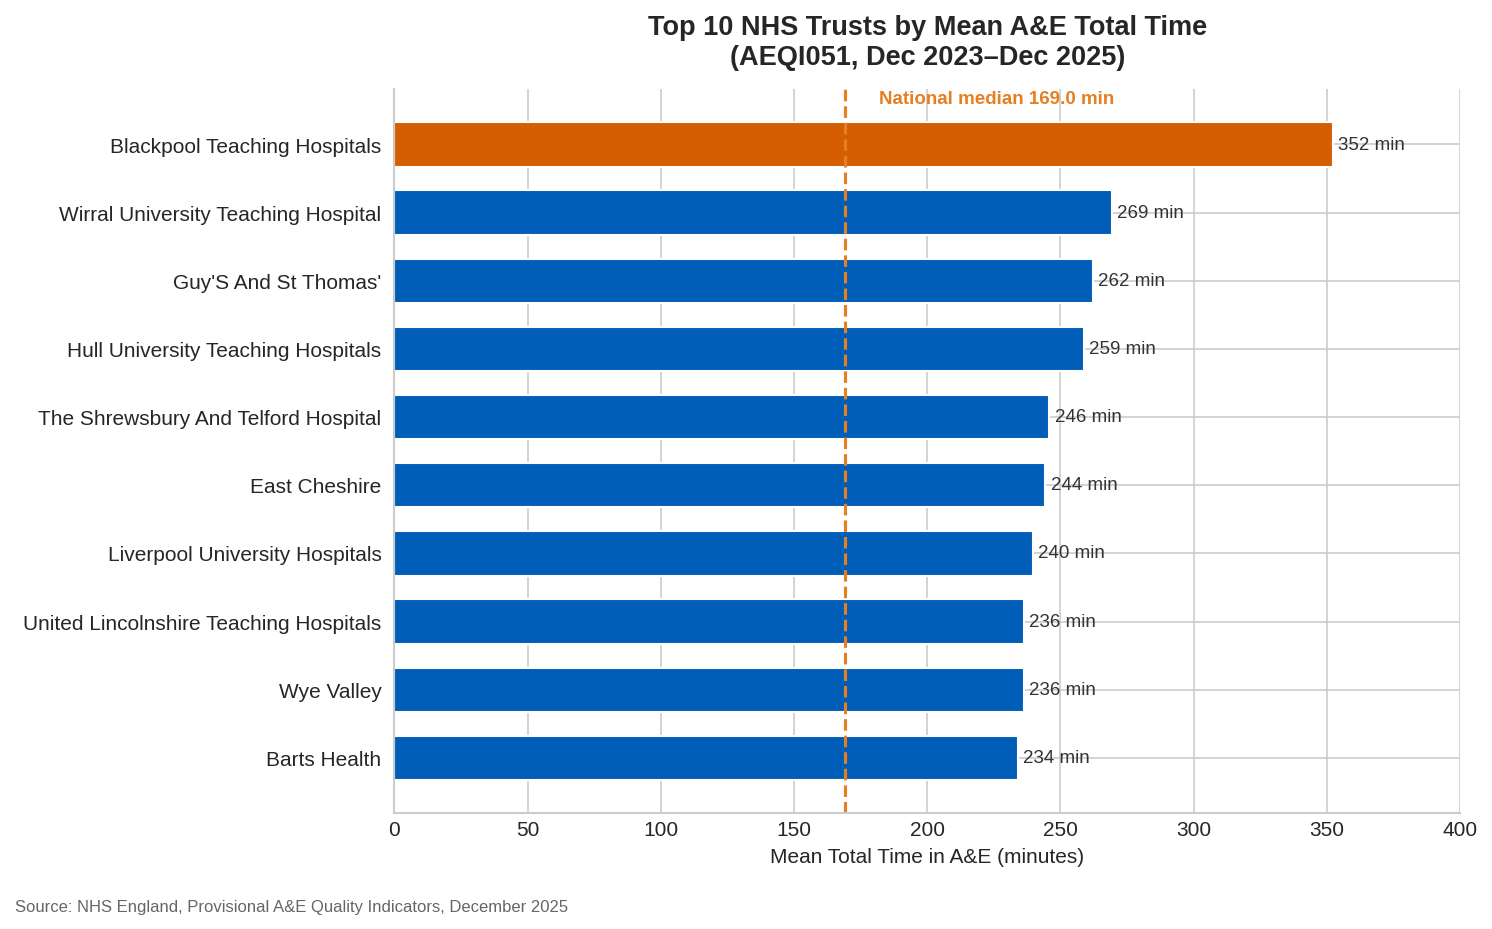

In [ ]:
from IPython.display import Image;
Image(OUTPUT_PATH + 'chart_top10_wait_time.png')


*   National benchmark is 169 minutes. All 10 Trusts here are worse than that.
*   9 of them cluster together, roughly 234–269 minutes.

*   **Blackpool** stands alone at 352 minutes more than double the benchmark, 83 minutes above the next worst Trust.

*   **Action:** the 9 need monitoring. Blackpool needs a standalone investigation now.


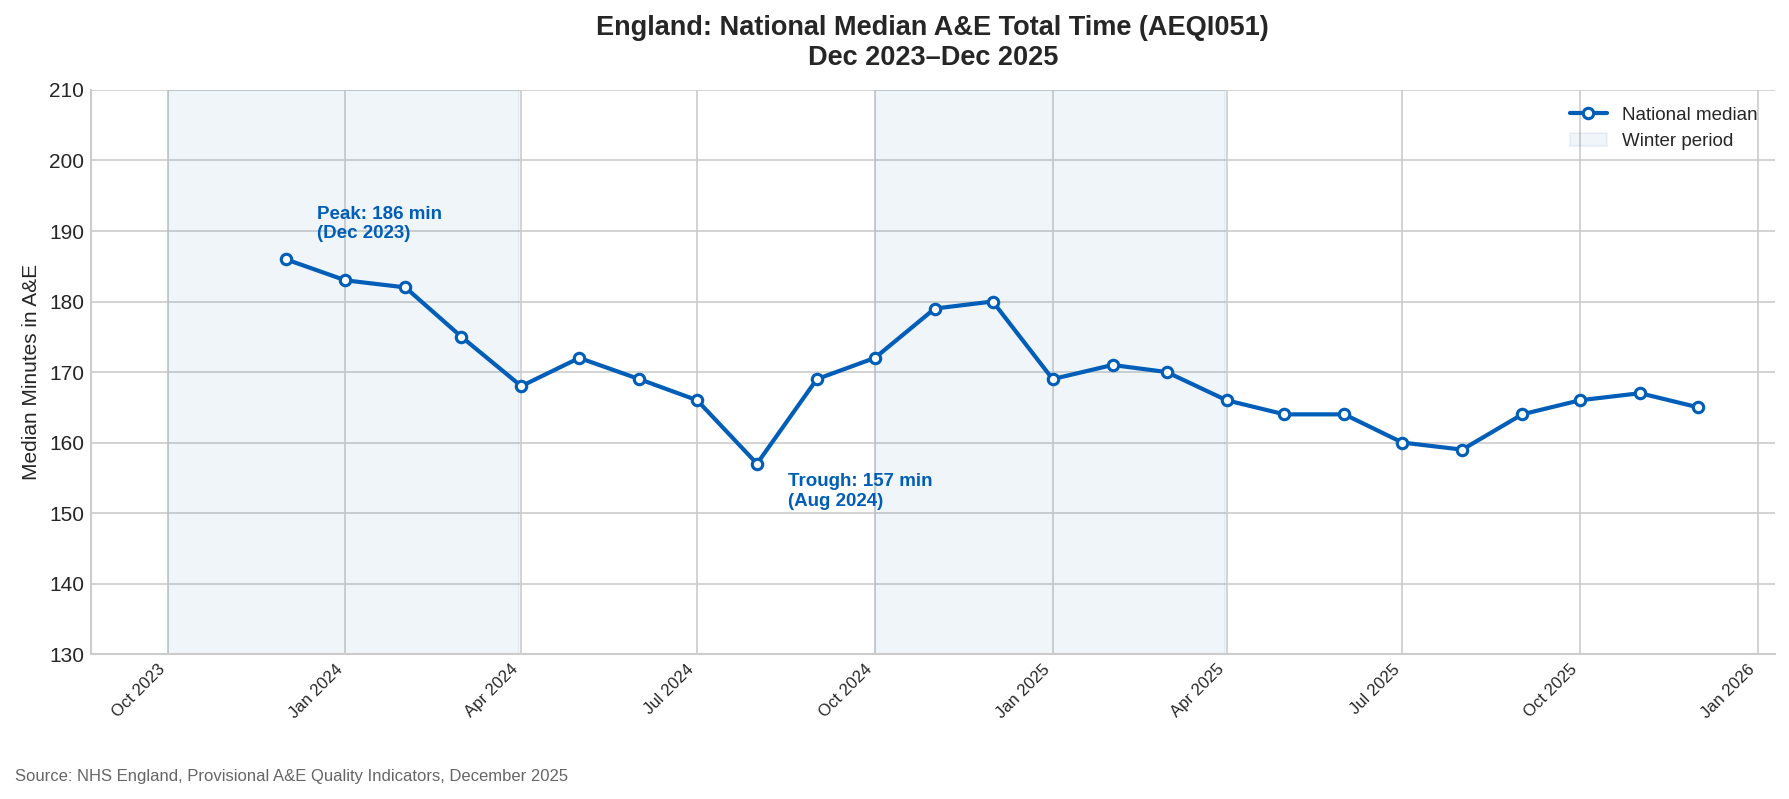

In [ ]:
from IPython.display import Image;
Image(OUTPUT_PATH + 'chart_england_trend.png')

*   Tracks 2 years, Dec 2023 to Dec 2025.

*   Worst point: 186 minutes, Dec 2023. Best point: 157 minutes, Aug 2024.

*  Winter (shaded) reliably pushes numbers back up clearest in Dec 2024, nearly back to 180.
*   Since spring 2025, performance has stabilised in a tighter band (159–167), better control than year one.


*  **Action:** Plan staffing ahead of winter the seasonal spike is predictable, not random.

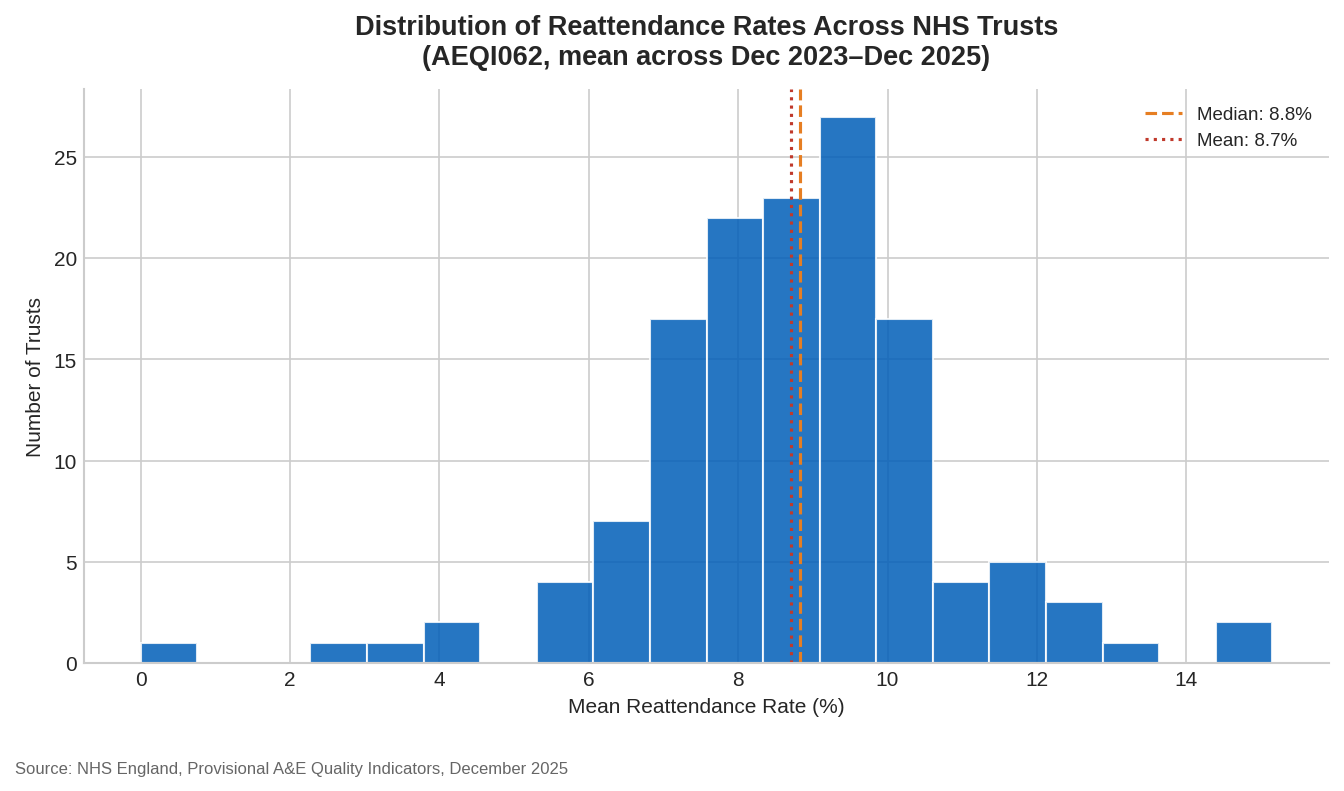

In [ ]:
from IPython.display import Image;
Image(OUTPUT_PATH + 'chart_reattendance_distribution.png')

*   Shows how 137 Trusts compare on patients returning within 7 days.

*   Most Trusts (majority) sit in a normal 7–10% range mean and median almost identical, so this is a stable, consistent system for most of the country.

*   But roughly 27 Trusts sit above 10%, some as high as 14–15% a distinct group with a different problem.
*   **Action:** don't set one national target. Monitor the normal group, individually investigate the ~27 outliers.

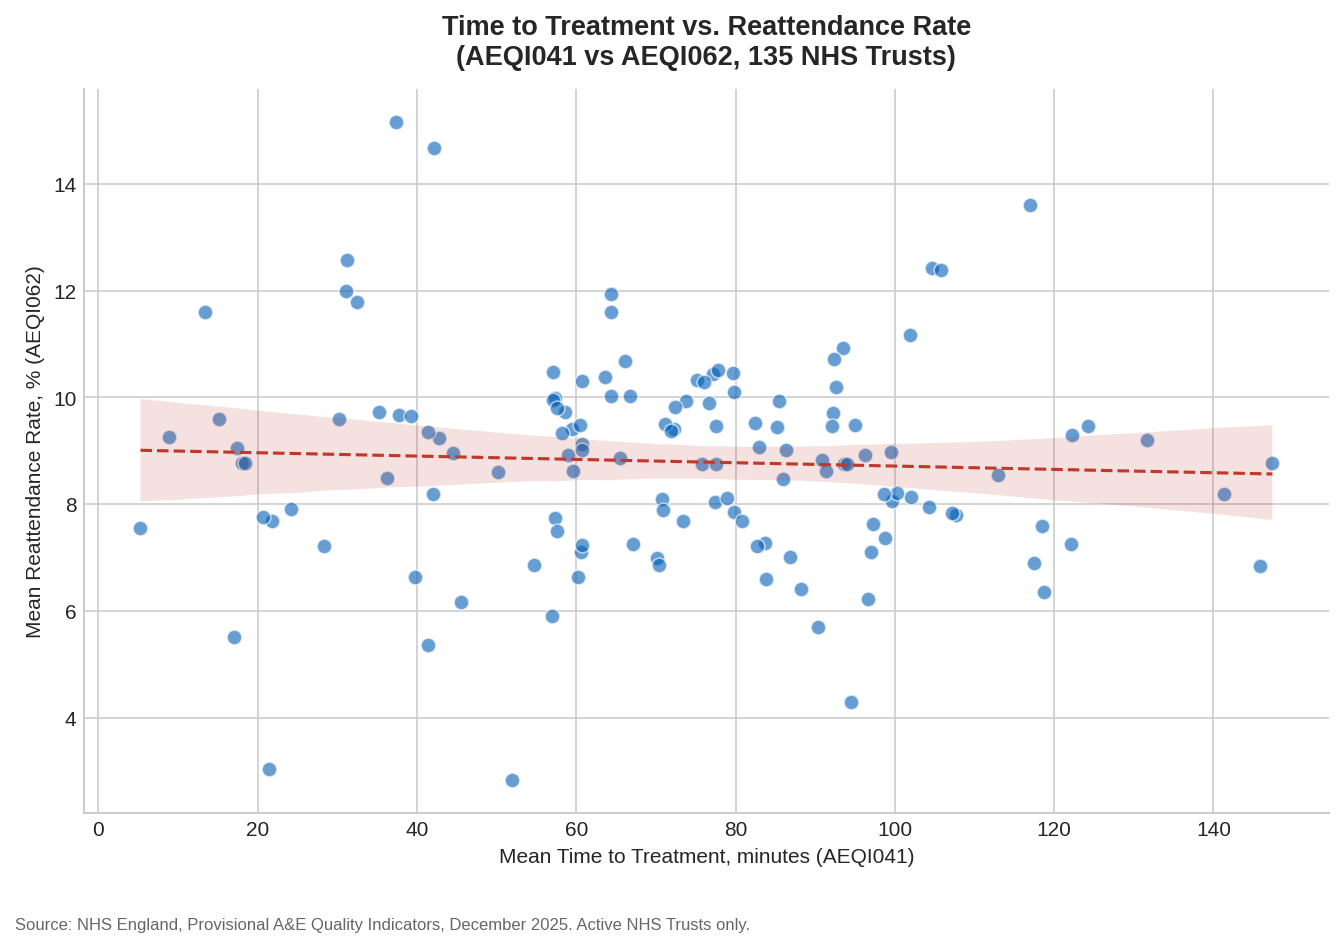

In [ ]:
from IPython.display import Image;
Image(OUTPUT_PATH + 'chart_treatment_vs_reattendance.png')

*   Tests whether slower treatment leads to more returning patients.

*   Answer: no meaningful link. The trend line is almost flat.
*   Two Trusts stand out regardless of the trend Northumbria Healthcare and Maidstone & Tunbridge Wells both fast treatment times, but the two highest reattendance rates in the whole dataset.


*  **Action:** speed alone doesn't explain return visits for these two investigate them separately, likely discharge or follow-up care factors, not wait times.



#**END**